In [1]:
from dask.distributed import LocalCluster

# https://forum.access-hive.org.au/t/netcdf-not-a-valid-id-errors/389/12
cluster = LocalCluster(threads_per_worker=1)          # Fully-featured local Dask cluster
client = cluster.get_client()
client

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 37241 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:37241/status,
Dashboard: http://127.0.0.1:37241/status,Workers: 56
Total threads: 56,Total memory: 1.11 TiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:43691,Workers: 56
Dashboard: http://127.0.0.1:37241/status,Total threads: 56
Started: Just now,Total memory: 1.11 TiB
Comm: tcp://127.0.0.1:34359,Total threads: 1
Dashboard: http://127.0.0.1:36933/status,Memory: 20.25 GiB
Nanny: tcp://127.0.0.1:41017,


2026-06-09 16:00:31,073 - distributed.nanny.memory - WARNING - Worker tcp://127.0.0.1:41069 (pid=2600014) exceeded 95% memory budget. Restarting...
2026-06-09 16:00:38,323 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:41069' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {('open_dataset-H2O_m-cf7c9a5d6c1aab5505f0a9fca7926c24', 0, 0, 0, 0), ('getitem-6416a6b04b16dc3a51c275f0d7c31cea', 0, 0, 0, 0)} (stimulus_id='handle-worker-cleanup-1781013638.3235602')
2026-06-09 16:00:38,980 - distributed.nanny - WARNING - Restarting worker


In [2]:
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import sys
from pathlib import Path
from string import ascii_lowercase, ascii_uppercase

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import HTML, Image, display
from scipy import stats
from cmap import Colormap

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


In [3]:
def process_daily(ds, deseasonalize=False):
    ds = ds.drop_vars(["var152", "time_bnds", "lat_bnds"], errors="ignore")
    time_arr = ds.time.values
    ds['time'] = pd.to_datetime(np.floor(time_arr), format = '%Y%m%d')
    #ds["time"] = pd.date_range("2021-01", freq="D", periods=ds.time.shape[0])
    ds["plev"] = ds.plev.values / 100.0
    ds["plev"].attrs["units"] = "hPa"
    ds["plev"].attrs["long_name"] = "pressure"
    ds["plev"].attrs["standard_name"] = "pressure"

    if deseasonalize:
        ds = anomalize_func(ds)  # deseasonalize_func(ds)

    return ds#.sel(plev=slice(0.1, 100))

In [4]:
xr.set_options(keep_attrs=True)
rootpath = Path("/sto0/data/Intermediate/Hunga_Tonga_byAles/")
infile_path =rootpath / "ht"
plt.rcParams.update({"font.size": 22})

# Dataset loading

## T U V

In [5]:
what = "ta-ua-va_2021-2025.nc"
infiles_w = list(infile_path.glob(f"socol4_htt1*{what}"))
infiles_wo = list(infile_path.glob(f"socol4_htt2*{what}"))

In [6]:
ds_w = xr.open_mfdataset(
    infiles_w,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    concat_dim=["ens"],
    # chunks = dict(plev = 1, time = 365)
).pipe(
    process_daily, deseasonalize=False
)  # .chunk(plev = 1, time = 365)
# ds_w_wv["ens"] = ens_name_ls
ds_w

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.ht

<xarray.Dataset> Size: 190GB
Dimensions:  (ens: 10, time: 1826, plev: 47, lat: 96, lon: 192)
Coordinates:
  * time     (time) datetime64[ns] 15kB 2021-01-01 2021-01-02 ... 2025-12-31
  * plev     (plev) float64 376B 0.009946 0.04281 0.1112 ... 995.4 1.009e+03
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
Dimensions without coordinates: ens
Data variables:
    var130   (ens, time, plev, lat, lon) float32 63GB dask.array<chunksize=(1, 1826, 47, 96, 192), meta=np.ndarray>
    v        (ens, time, plev, lat, lon) float32 63GB dask.array<chunksize=(1, 1826, 47, 96, 192), meta=np.ndarray>
    u        (ens, time, plev, lat, lon) float32 63GB dask.array<chunksize=(1, 1826, 47, 96, 192), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    institution:  Max Planck Institute for Meteorology
    history:      Thu Mar 28 16:15:52 2024: cdo cat Postproc_example-va-paral...
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [8]:
ds_wo = xr.open_mfdataset(
    infiles_wo,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    concat_dim=["ens"],
    # chunks = dict(plev = 1, time = 365)
).pipe(
    process_daily, deseasonalize=False
)  # .chunk(plev = 1, time = 365)
# ds_w_wv["ens"] = ens_name_ls
ds_wo

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.ht

<xarray.Dataset> Size: 190GB
Dimensions:  (ens: 10, time: 1826, plev: 47, lat: 96, lon: 192)
Coordinates:
  * time     (time) datetime64[ns] 15kB 2021-01-01 2021-01-02 ... 2025-12-31
  * plev     (plev) float64 376B 0.009946 0.04281 0.1112 ... 995.4 1.009e+03
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
Dimensions without coordinates: ens
Data variables:
    var130   (ens, time, plev, lat, lon) float32 63GB dask.array<chunksize=(1, 1461, 47, 96, 192), meta=np.ndarray>
    v        (ens, time, plev, lat, lon) float32 63GB dask.array<chunksize=(1, 1461, 47, 96, 192), meta=np.ndarray>
    u        (ens, time, plev, lat, lon) float32 63GB dask.array<chunksize=(1, 1461, 47, 96, 192), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    institution:  Max Planck Institute for Meteorology
    history:      Thu Mar 28 16:16:11 2024: cdo cat Postproc_example-va-paral...
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [9]:
dims4ave = ['lon']
sel_dict = dict(time = slice("2024-09", "2025-04"))
arr1_u = ds_w['u'].mean(dims4ave).sel(**sel_dict).sel(lat = 60, method = 'nearest').load()
arr2_u = ds_wo['u'].mean(dims4ave).sel(**sel_dict).sel(lat = 60, method = 'nearest').load()

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources

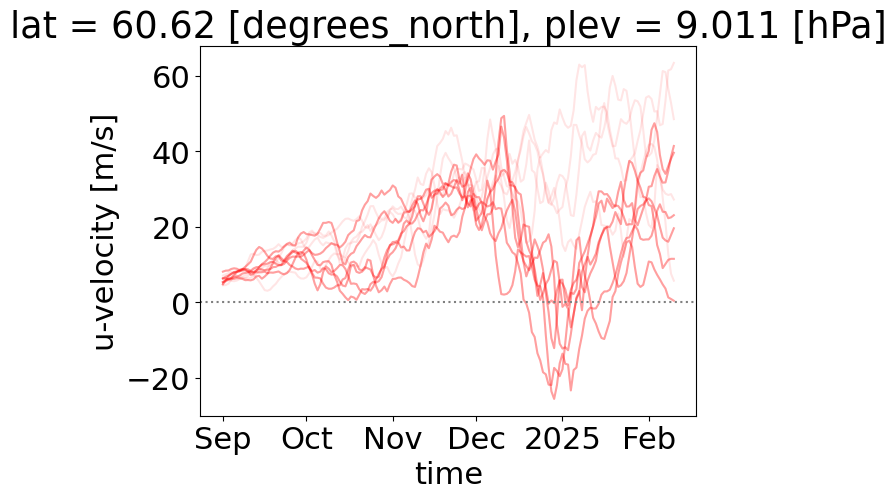

In [39]:
temp = arr1_u.sel(plev = 10, method = 'nearest').sel(time = slice(None,'2025-02-10'))
temp.plot.line(hue = 'ens', color = 'r', alpha = 0.1, add_legend = False)
mask = np.any(temp <= 0, axis = 1)
temp[mask,:].plot.line(hue = 'ens', color = 'r', alpha = 0.3, add_legend = False)
plt.axhline(0, ls = 'dotted', color = 'gray')

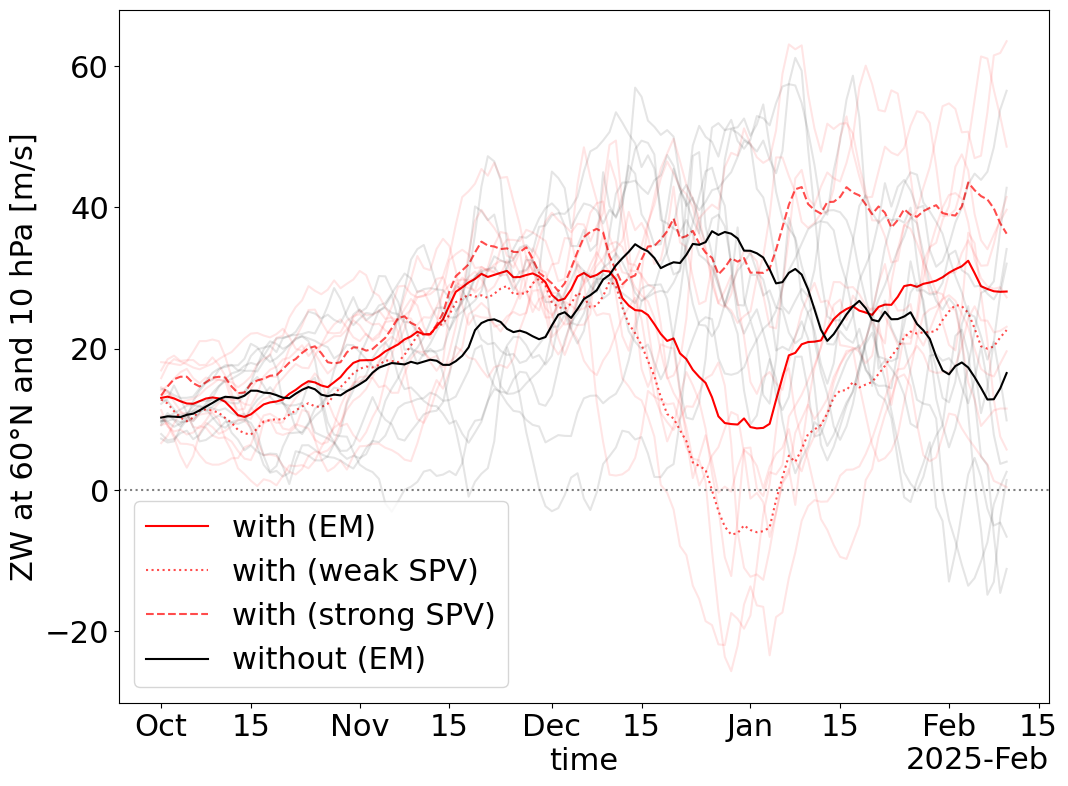

In [99]:
fig, ax = plt.subplots(figsize = (12,9))
temp = arr1_u.sel(plev = 10, method = 'nearest').sel(time = slice('2024-10','2025-02-10'))
temp.plot.line(hue = 'ens', color = 'r', alpha = 0.1, add_legend = False, ax = ax)
temp.mean('ens').plot(color = 'r', label = 'with (EM)', ax = ax)

mask = np.any(temp <= 0, axis = 1)
temp[mask,:].mean('ens').plot.line(hue = 'ens', color = 'r', alpha = 0.7, add_legend = False, ls = 'dotted', label = 'with (weak SPV)')
temp[~mask,:].mean('ens').plot.line(hue = 'ens', color = 'r', alpha = 0.7, add_legend = False, ls = 'dashed', label = 'with (strong SPV)')

ax.axhline(0, ls = 'dotted', color = 'gray')

temp = arr2_u.sel(plev = 10, method = 'nearest').sel(time = slice('2024-10','2025-02-10'))
temp.plot.line(hue = 'ens', color = 'k', alpha = 0.1, add_legend = False, ax = ax)
temp.mean('ens').plot(color = 'k', label = 'without (EM)', ax = ax)
ax.legend()
ax.set_title('')
ax.set_ylabel('ZW at 60°N and 10 hPa [m/s]')

plt.savefig('ZW_cluster_202410-202502.pdf')

In [68]:
soi_w = xr.open_dataset('soi_w.nc')
soi_wo = xr.open_dataset('soi_wo.nc')

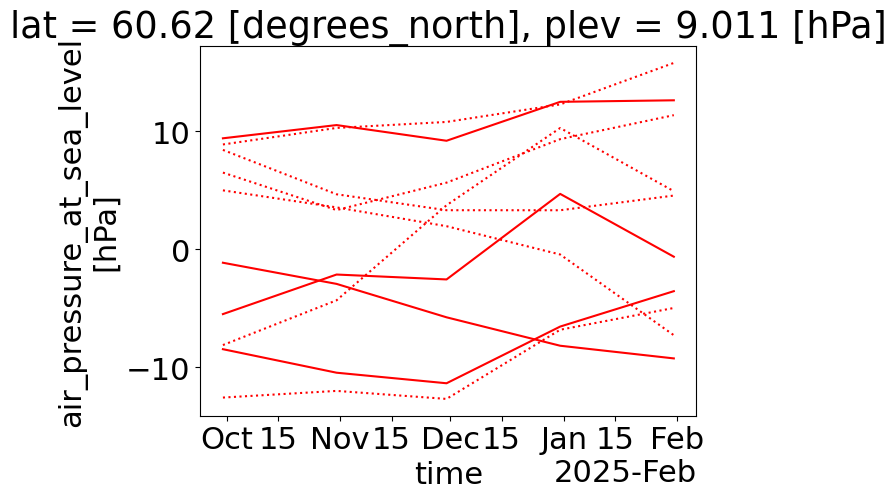

In [81]:
soi_w_sel = soi_w['psl'].sel(time = slice('2024-09','2025-02-10'))
soi_w_sel[mask,:].plot.line(hue = 'ens', add_legend = False, color = 'r', ls = 'dotted')
soi_w_sel[~mask,:].plot.line(hue = 'ens', add_legend = False, color = 'r')

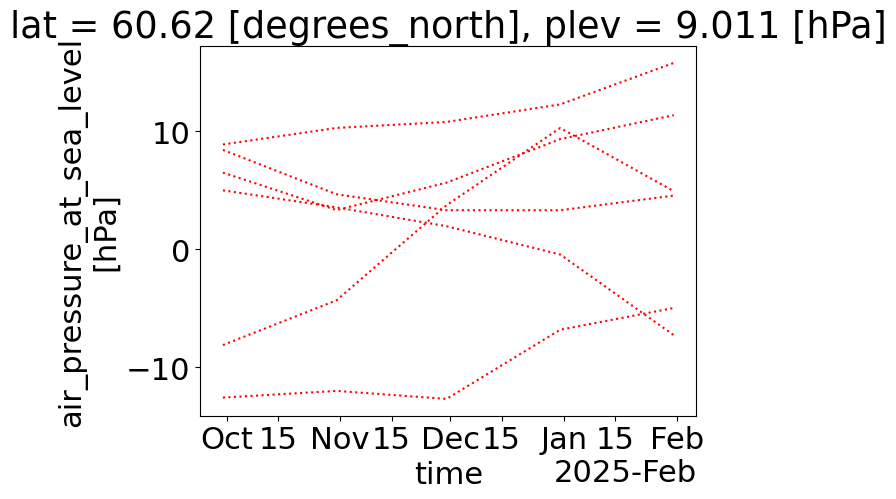

In [85]:
soi_w_sel[mask,:].plot.line(hue = 'ens', add_legend = False, color = 'r', ls = 'dotted')

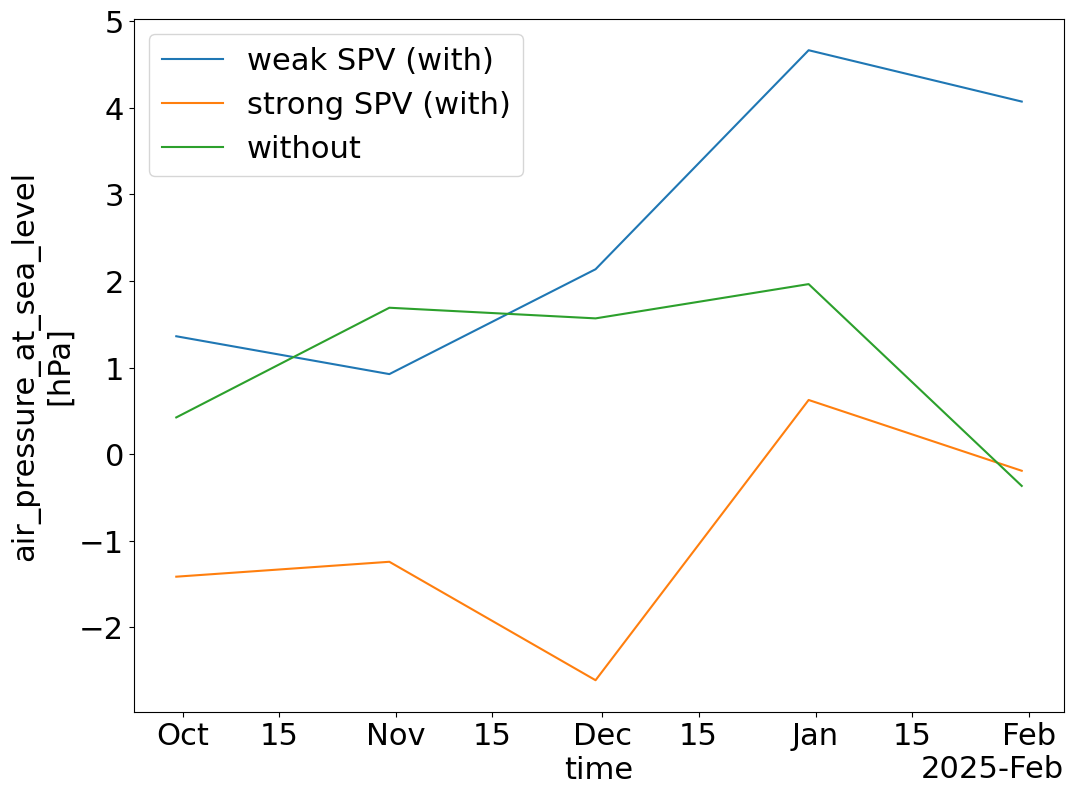

In [84]:
soi_w_sel[mask,:].mean('ens').plot(label = 'weak SPV (with)', size = 9)
soi_w_sel[~mask,:].mean('ens').plot(label = 'strong SPV (with)')
soi_wo['psl'].sel(time = slice('2024-09','2025-02-10')).mean('ens').plot(label = 'without')
plt.legend()

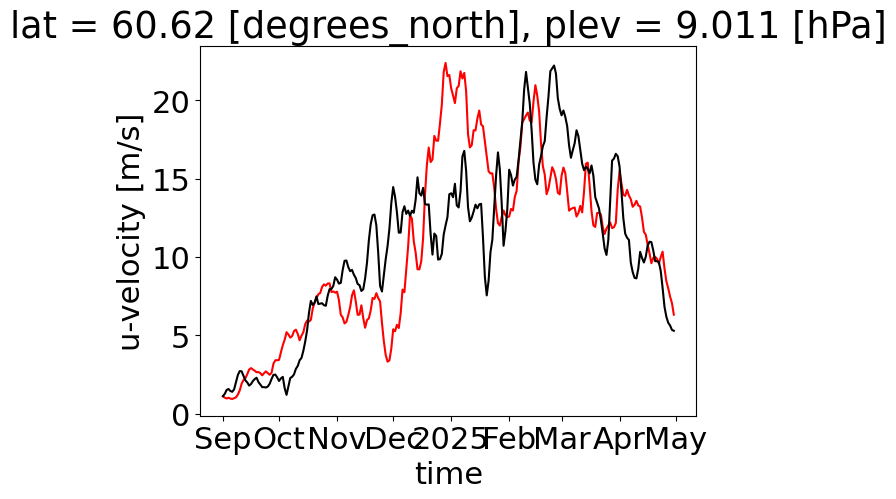

In [63]:
temp = arr1_u.sel(plev = 10, method = 'nearest')#.sel(time = slice(None,'2025-04-10'))
temp.std('ens').plot(color = 'r')

temp = arr2_u.sel(plev = 10, method = 'nearest')#.sel(time = slice(None,'2025-02-10'))
temp.std('ens').plot(color = 'k')

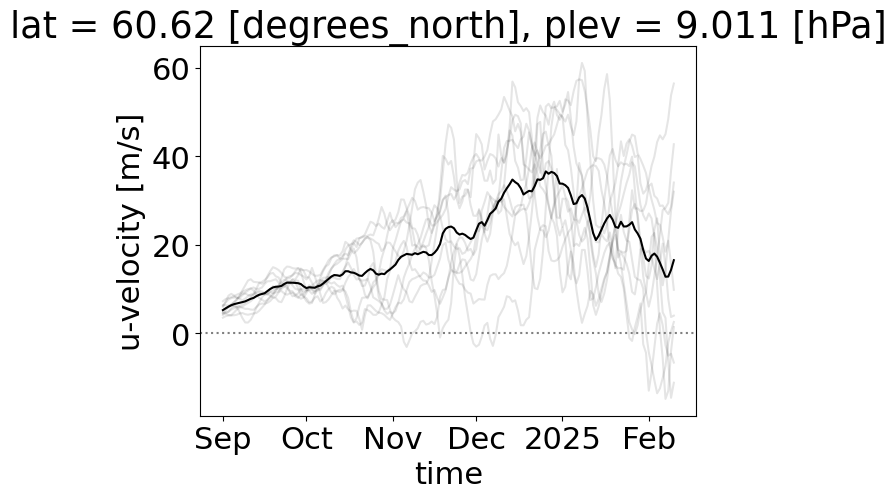

In [43]:
temp = arr2_u.sel(plev = 10, method = 'nearest').sel(time = slice(None,'2025-02-10'))
temp.plot.line(hue = 'ens', color = 'k', alpha = 0.1, add_legend = False)
temp.mean('ens').plot(color = 'k')
#mask = np.any(temp <= 0, axis = 1)
#temp[mask,:].plot.line(hue = 'ens', color = 'r', alpha = 0.3, add_legend = False)
plt.axhline(0, ls = 'dotted', color = 'gray')

In [10]:
diff_u_sel_pcap = arr1_u.mean('ens')-arr2_u.mean('ens')
diff_u_sel_pcap.attrs['units'] = 'm/s'
diff_u_sel_pcap.attrs['long_name'] = 'zonal wind'

t_stat, p_values = stats.ttest_ind(
    arr1_u, arr2_u, equal_var=False
)  # , nan_policy = nan_policy)
diff_u_sel_pcap_pv = xr.DataArray(p_values, coords=diff_u_sel_pcap.coords)


In [11]:
dims4ave = ['lon']
sel_dict = dict(lat = slice(None,60), time = slice("2024-09", "2025-04"))
arr1 =  ds_w['var130'].mean(dims4ave).sel(**sel_dict)
weights = np.cos(np.deg2rad(arr1.lat))
weights.name = "weights"
arr1 = arr1.weighted(weights).mean('lat').load()
arr2 = ds_wo['var130'].mean(dims4ave).sel(**sel_dict).weighted(weights).mean('lat').load()


diff_t_sel_pcap = arr1.mean('ens')-arr2.mean('ens')
diff_t_sel_pcap.attrs['units'] = 'K'
diff_t_sel_pcap.attrs['long_name'] = 'temperature'

t_stat, p_values = stats.ttest_ind(
    arr1, arr2, equal_var=False
)  # , nan_policy = nan_policy)
diff_t_sel_pcap_pv = xr.DataArray(p_values, coords=diff_t_sel_pcap.coords)


/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources

## WV

In [12]:
what = "H2O_m"
infiles_w = list(infile_path.glob(f"socol4_htt1*{what}*daily.nc"))
infiles_wo = list(infile_path.glob(f"socol4_htt2*{what}*daily.nc"))

In [13]:
time_arr = xr.open_mfdataset(
    infiles_w,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    concat_dim=["ens"],
    # chunks = dict(plev = 1, time = 365)
)['time'].values
 

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [14]:
ds_w_wv = xr.open_mfdataset(
    infiles_w,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    concat_dim=["ens"],
    # chunks = dict(plev = 1, time = 365)
).pipe(
    process_daily, deseasonalize=False
)  # .chunk(plev = 1, time = 365)
# ds_w_wv["ens"] = ens_name_ls
ds_w_wv

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


<xarray.Dataset> Size: 66GB
Dimensions:  (ens: 10, time: 1826, plev: 49, lat: 96, lon: 192)
Coordinates:
  * time     (time) datetime64[ns] 15kB 2021-01-01 2021-01-02 ... 2025-12-31
  * plev     (plev) float64 392B 0.009946 0.04281 0.1112 ... 995.4 1.009e+03
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
Dimensions without coordinates: ens
Data variables:
    H2O_m    (ens, time, plev, lat, lon) float32 66GB dask.array<chunksize=(1, 1826, 49, 96, 192), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    history:      Mon Feb 26 14:43:50 2024: cdo cat rr3.nc /scratch/snx3000/a...
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [15]:
ds_wo_wv = xr.open_mfdataset(
    infiles_wo,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    concat_dim=["ens"],
    # chunks = dict(plev = 1, time = 365)
).pipe(process_daily, deseasonalize=False)
ds_wo_wv

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/tmp/ipykernel_2579611/2679231195.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following 

<xarray.Dataset> Size: 66GB
Dimensions:  (ens: 10, time: 1826, plev: 49, lat: 96, lon: 192)
Coordinates:
  * time     (time) datetime64[ns] 15kB 2021-01-01 2021-01-02 ... 2025-12-31
  * plev     (plev) float64 392B 0.009946 0.04281 0.1112 ... 995.4 1.009e+03
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
Dimensions without coordinates: ens
Data variables:
    H2O_m    (ens, time, plev, lat, lon) float32 66GB dask.array<chunksize=(1, 1461, 49, 96, 192), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    history:      Mon Feb 26 16:11:55 2024: cdo cat rr3.nc /scratch/snx3000/a...
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [16]:
dims4ave = ['lon']
diff = ds_w_wv['H2O_m'].mean(dims4ave)-ds_wo_wv['H2O_m'].mean(dims4ave)
sel_dict = dict(lat = slice(None,60), time = slice("2023-09", "2024-04"))
diff_sel = diff.sel(**sel_dict).isel(ens = 0)
weights = np.cos(np.deg2rad(diff.lat))
weights.name = "weights"
diff_sel_pcap = diff_sel.weighted(weights).mean('lat').load()*1e6
diff_sel_pcap.attrs['units'] = 'ppmv'
#diff_sel_pcap.attrs['long_name'] = 'temperature'

2026-06-09 15:42:24,281 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 14.20 GiB -- Worker memory limit: 20.25 GiB


In [17]:
dims4ave = ['lon']
sel_dict = dict(lat = slice(None,60), time = slice("2024-09", "2025-04"))
arr1 = ds_w_wv['H2O_m'].mean(dims4ave).sel(**sel_dict)
weights = np.cos(np.deg2rad(arr1.lat))
weights.name = "weights"
arr1 = arr1.weighted(weights).mean('lat').load()*1e6
arr2 = ds_wo_wv['H2O_m'].mean(dims4ave).sel(**sel_dict).weighted(weights).mean('lat').load()*1e6
#diff = arr1 - arr2
diff_sel_pcap = arr1.mean('ens') - arr2.mean('ens')
diff_sel_pcap.attrs['units'] = 'ppmv'
#diff_sel_pcap.attrs['long_name'] = 'temperature'

t_stat, p_values = stats.ttest_ind(
    arr1, arr2, equal_var=False
)  # , nan_policy = nan_policy)
diff_sel_pcap_pv = xr.DataArray(p_values, coords=diff_sel_pcap.coords)

2026-06-09 15:52:24,937 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 14.18 GiB -- Worker memory limit: 20.25 GiB
2026-06-09 15:52:29,974 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 14.18 GiB -- Worker memory limit: 20.25 GiB
2026-06-09 15:52:30,085 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. 

## EHF

In [18]:
ds_diff_2324 = xr.load_dataset('../ehf_diff_2023-09_2024-04.nc')
ds_diff_2425 = xr.load_dataset('../ehf_diff_2024-09_2025-04.nc')



## NAM

In [17]:
nam_wo = xr.open_dataset('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt2-all_NAM_2021-2025.nc')['nam']
nam_w = xr.open_dataset('/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/socol4_htt1-all_NAM_2021-2025.nc')['nam']

In [18]:
diff_nam = nam_w.mean("ens") - nam_wo.mean("ens")
_, p_values = stats.ttest_ind(nam_w, nam_wo, equal_var=False)
diff_nam_pv = xr.DataArray(p_values, coords=diff_nam.coords)
#diff_pv_fdr = xr_multipletest(diff_pv)[1]

## ozone

In [19]:
what = "ozone"
infiles_w = list(infile_path.glob(f"socol4_htt1*{what}*daily.nc"))
infiles_wo = list(infile_path.glob(f"socol4_htt2*{what}*daily.nc"))

In [20]:
ds_w_o3 = xr.open_mfdataset(
    infiles_w,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    concat_dim=["ens"],
    # chunks = dict(plev = 1, time = 365)
).pipe(
    process_daily, deseasonalize=False
)  # .chunk(plev = 1, time = 365)
# ds_w_wv["ens"] = ens_name_ls
ds_w_o3

/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/hpx/Data_impb/kales/conda/envs/myenv/lib/python3.11/site-packages/pvxarray/_version.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


<xarray.Dataset> Size: 836MB
Dimensions:  (ens: 10, time: 1461, lat: 96, lon: 1, plev: 49)
Coordinates:
  * time     (time) datetime64[ns] 12kB 2022-01-01 2022-01-02 ... 2025-12-31
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * lon      (lon) float64 8B 0.0
  * plev     (plev) float64 392B 0.009946 0.04281 0.1112 ... 995.4 1.009e+03
Dimensions without coordinates: ens
Data variables:
    aps      (ens, time, lat, lon) float32 6MB dask.array<chunksize=(1, 1461, 96, 1), meta=np.ndarray>
    geosp    (ens, time, lat, lon) float32 6MB dask.array<chunksize=(1, 1461, 96, 1), meta=np.ndarray>
    O3_m     (ens, time, plev, lat, lon) float32 275MB dask.array<chunksize=(1, 1461, 49, 96, 1), meta=np.ndarray>
    HO2_m    (ens, time, plev, lat, lon) float32 275MB dask.array<chunksize=(1, 1461, 49, 96, 1), meta=np.ndarray>
    OH_m     (ens, time, plev, lat, lon) float32 275MB dask.array<chunksize=(1, 1461, 49, 96, 1), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.1.1 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  Max-Planck-Institute for Meteorology
    history:      Fri May 16 12:10:28 2025: cdo ml2pl,0.9946,4.2806,11.1230,2...
    CDO:          Climate Data Operators version 2.1.1 (https://mpimet.mpg.de...

In [21]:
ds_wo_o3 = xr.open_mfdataset(
    infiles_wo,
    parallel=True,  #  will be performed in parallel using dask.delayed
    combine="nested",
    concat_dim=["ens"],
    # chunks = dict(plev = 1, time = 365)
).pipe(process_daily, deseasonalize=False)
ds_wo_o3

<xarray.Dataset> Size: 836MB
Dimensions:  (ens: 10, time: 1461, lat: 96, lon: 1, plev: 49)
Coordinates:
  * time     (time) datetime64[ns] 12kB 2022-01-01 2022-01-02 ... 2025-12-31
  * lat      (lat) float64 768B 88.57 86.72 84.86 83.0 ... -84.86 -86.72 -88.57
  * lon      (lon) float64 8B 0.0
  * plev     (plev) float64 392B 0.009946 0.04281 0.1112 ... 995.4 1.009e+03
Dimensions without coordinates: ens
Data variables:
    aps      (ens, time, lat, lon) float32 6MB dask.array<chunksize=(1, 1461, 96, 1), meta=np.ndarray>
    geosp    (ens, time, lat, lon) float32 6MB dask.array<chunksize=(1, 1461, 96, 1), meta=np.ndarray>
    O3_m     (ens, time, plev, lat, lon) float32 275MB dask.array<chunksize=(1, 1461, 49, 96, 1), meta=np.ndarray>
    HO2_m    (ens, time, plev, lat, lon) float32 275MB dask.array<chunksize=(1, 1461, 49, 96, 1), meta=np.ndarray>
    OH_m     (ens, time, plev, lat, lon) float32 275MB dask.array<chunksize=(1, 1461, 49, 96, 1), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.1.1 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  Max-Planck-Institute for Meteorology
    history:      Fri May 16 12:10:49 2025: cdo ml2pl,0.9946,4.2806,11.1230,2...
    CDO:          Climate Data Operators version 2.1.1 (https://mpimet.mpg.de...

In [22]:
weights = np.cos(np.deg2rad(ds_w_o3.lat))
weights.name = "weights"

dims4ave = ['ens']
sel_dict = dict(lat = slice(None,60), time = slice("2024-09", "2025-04"))
arr1_o3 =  ds_w_o3['O3_m'].sel(**sel_dict).weighted(weights).mean('lat').load()
arr2_o3 =  ds_wo_o3['O3_m'].sel(**sel_dict).weighted(weights).mean('lat').load()

In [23]:
diff_o3_rel = ((arr1_o3.mean("ens")-arr2_o3.mean("ens")) / arr1_o3.mean("ens") * 100)
diff_o3_rel.attrs['units'] = '%'
diff_o3_rel.attrs['long_name'] = 'O3 VMR'


diff_o3 = (arr1_o3.mean("ens")*1e6-arr2_o3.mean("ens")*1e6) 
#diff_o3 = ((arr1-arr2) ).mean("ens")
diff_o3.attrs['units'] = 'ppmv'
diff_o3.attrs['long_name'] = 'O3 VMR'

t_stat, p_values = stats.ttest_ind(
    arr1_o3*1e6, arr2_o3*1e6, equal_var=False
)  # , nan_policy = nan_policy)
diff_o3_pv = xr.DataArray(p_values, coords=diff_o3.coords)

# visualization

### 2024-2025

TE+NAM+WV+O3_time-evolution_2024-2025.pdf


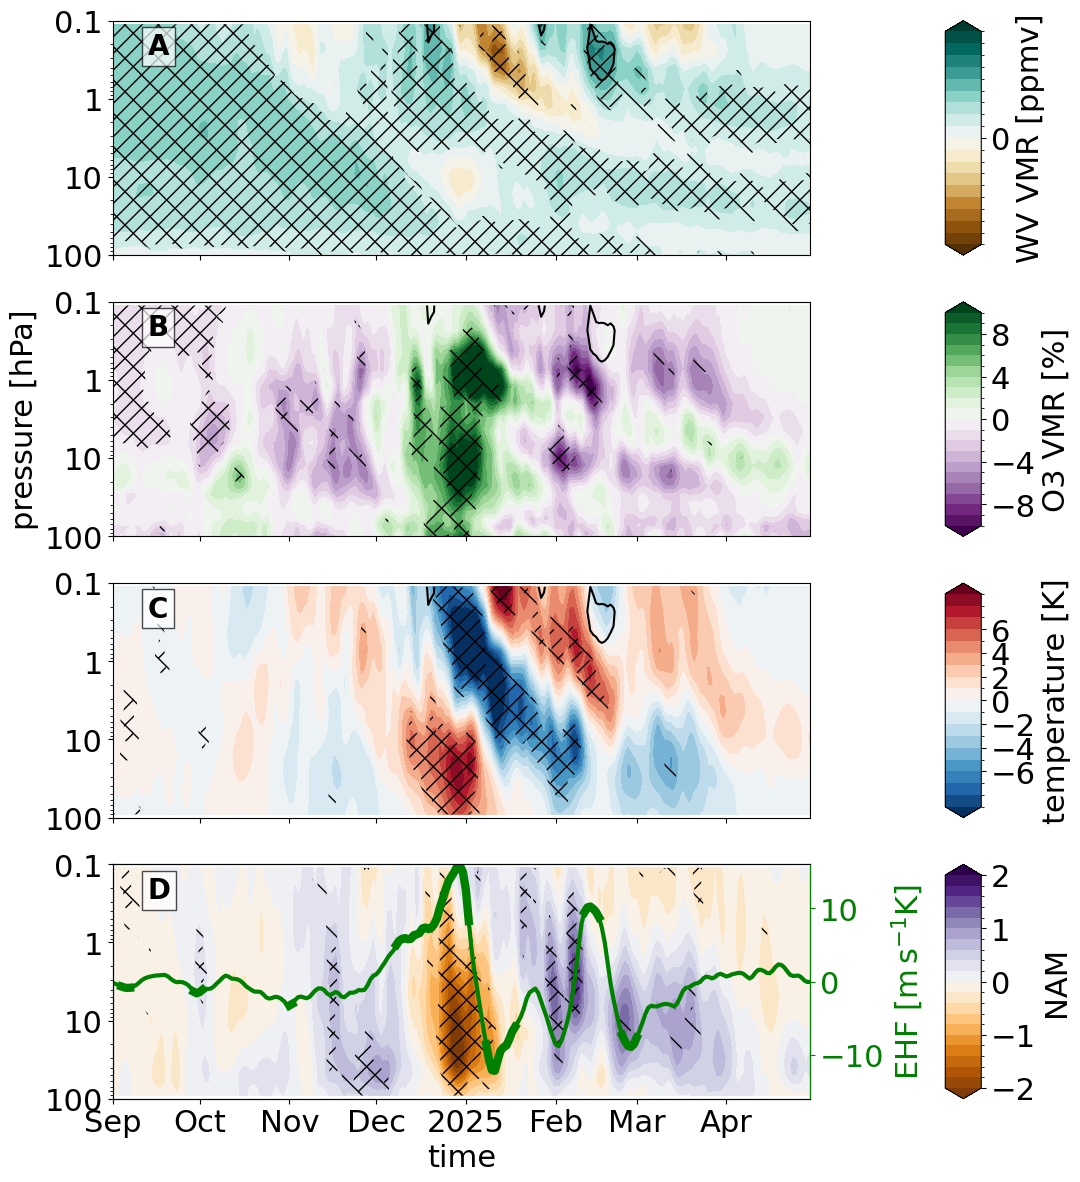

In [26]:
n_rows = 4
f, axes = plt.subplots(n_rows, 1, figsize=(9, 14), sharex=True)
p_ls = []
ax = axes[0]
p = (diff_sel_pcap).plot.contourf(
    x = 'time', yincrease = False, 
    robust=False, cmap="BrBG", 
    center = 0, extend = 'both', 
    levels = 21, ax = ax,
    add_colorbar = False,
)
p_ls.append(p)
(diff_sel_pcap).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.5], colors = ['k'],
)


kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    ax=ax,
    # linewidths=np.linspace(1, 4, 4),
)

diff_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)
kwargs['levels'] = [0,0.1]
kwargs['hatches'] = ["\\",  None]
diff_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)


# ozone
ax = axes[1]
p = (diff_o3.squeeze()).plot.contourf(
    x = 'time', yincrease = False, 
    robust=True, levels = 21,
    cmap = 'PRGn',
    ax = ax, extend='both',
    add_colorbar = False,
)
p_ls.append(p)

kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    ax=ax,
    # linewidths=np.linspace(1, 4, 4),
)

diff_o3_pv.squeeze().plot.contourf(x="time", **kwargs)
kwargs['levels'] = [0,0.1]
kwargs['hatches'] = ["\\",  None]
diff_o3_pv.squeeze().plot.contourf(x="time", **kwargs)

(diff_sel_pcap).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.5], colors = ['k'],
)

ax = axes[2]
p = (diff_t_sel_pcap).plot.contourf(
    x = 'time', yincrease = False, 
    robust=True, levels = 21,
    ax = ax, extend='both',
    add_colorbar = False,
)
p_ls.append(p)

(diff_sel_pcap).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.5], colors = ['k'],
)

kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    ax=ax,
    # linewidths=np.linspace(1, 4, 4),
)

diff_t_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)
kwargs['levels'] = [0,0.1]
kwargs['hatches'] = ["\\",  None]
diff_t_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)



# NAM
ax = axes[-1]
time_sel_dict = dict(time = slice("2024-09", "2025-04"), plev = slice(0.1,100))
p2 = diff_nam.sel(**time_sel_dict).plot.contourf(
    x="time", yincrease=False, 
    levels=21, #robust=False, 
    extend = 'both', 
    cmap="PuOr", ax = ax,
    #cbar_kwargs=dict(label=r"NAM"),
    vmax = 2,
    add_colorbar = False,
)

kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    ax=ax,
    # linewidths=np.linspace(1, 4, 4),
)

diff_nam_pv.sel(**time_sel_dict).plot.contourf(x="time", **kwargs)
kwargs['levels'] = [0,0.1]
kwargs['hatches'] = ["\\",  None]
diff_nam_pv.sel(**time_sel_dict).plot.contourf(x="time", **kwargs)



for i,ax in enumerate(axes):
    ax.set_yscale('log')
    ax.set_yticks([100,10,1,0.1])
    fmt = mpl.ticker.FormatStrFormatter("%g")
    ax.yaxis.set_major_formatter(fmt)
    
    label = ascii_uppercase[i]
    ax.text(
            0.05,
            0.95,
            label,
            transform=ax.transAxes,
            fontsize=20,
            fontweight="bold",
            va="top",
            bbox={"alpha": 0.7, "facecolor": "white"},
        )
    if i != 1:
        ax.set_ylabel('')
    if i != n_rows-1:
        ax.set_xlabel('')

ax2 = ax.twinx()
temp = ds_diff_2425.sel(plev = 100, method='nearest')#.sel(time = time_slice)
temp['ehf'].plot(ax = ax2, color = 'green', lw = 3)
temp['ehf'].where(temp['pv'] < 0.1).plot(ax = ax2, color = 'green', lw = 6)

ax2.set_ylim(-16,16)
ax2.set_title('')
kwargs = dict(color = 'g')
ax2.set_ylabel(r'EHF [$\mathrm{m\,s^{-1} K}$]',  **kwargs)
ax2.spines['right'].set_color('green')
#ax2.yaxis.label.set_color('red')
ax2.tick_params(axis='y', colors='green')

cx_shift= 0.15
label_ls = ['WV VMR [ppmv]','O3 VMR [%]','temperature [K]']
ticks_ls = [[-1,0,1],[-8,-4,0,4,8],[-6,-4,-2,0,2,4,6],[-2,-1,0,1,2]]
for i, label, p, ticks in zip(range(3),label_ls,p_ls, ticks_ls):
    posn = axes[i].get_position()
    cax = f.add_axes([0.1,-0.1,0.5,0.1])
    
    cax.set_position([posn.x0+posn.width+cx_shift, posn.y0+0.0, 0.04, posn.height])
    f.colorbar(p, cax=cax, orientation='vertical', label=label, extend = 'both', spacing = 'proportional', ticks = ticks)

posn = axes[-1].get_position()
cax = f.add_axes([0.1,-0.1,0.5,0.1])
cx_shift= 0.15
cax.set_position([posn.x0+posn.width+cx_shift, posn.y0+0.0, 0.04, posn.height])
f.colorbar(p2, cax=cax, orientation='vertical', label='NAM', extend = 'both', spacing = 'proportional', ticks = [-6,-3,-2,-1,0,1,2,3,6])


outfile = f"TE+NAM+WV+O3_time-evolution_2024-2025.pdf"
print(outfile)
plt.savefig(outfile, bbox_inches="tight")

In [ ]:
n_rows = 4
time_sel_dict = dict(plev = slice(0.1,200)) # time = slice("2023-09", "2024-04"),

f, axes = plt.subplots(n_rows, 1, figsize=(9, 14), sharex=True)
p_ls = []
ax = axes[0]
p = (diff_sel_pcap).plot.contourf(
    x = 'time', yincrease = False, 
    robust=False, cmap="BrBG", 
    extend = 'both',     
    levels = np.arange(-1.8,2,0.2), ax = ax,
    add_colorbar = False,
)
p_ls.append(p)
CS = (diff_sel_pcap).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.25,0.5,1], colors = ['k'],
)
ax.clabel(CS)

In [ ]:
n_rows = 4
time_sel_dict = dict(plev = slice(0.1,200)) # time = slice("2023-09", "2024-04"),

f, axes = plt.subplots(n_rows, 1, figsize=(9, 14), sharex=True)
p_ls = []
ax = axes[0]
p = (diff_sel_pcap).plot.contourf(
    x = 'time', yincrease = False, 
    robust=False, cmap="BrBG", 
    extend = 'both',     
    levels = np.arange(-1.8,2,0.2), ax = ax,
    add_colorbar = False,
)
p_ls.append(p)
CS = (diff_sel_pcap).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.25,0.5,1], colors = ['k'],
)
ax.clabel(CS)

kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    ax=ax,
    # linewidths=np.linspace(1, 4, 4),
)

diff_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)
kwargs['levels'] = [0,0.1]
kwargs['hatches'] = ["\\",  None]
diff_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)


# ozone
ax = axes[1]
p = (diff_o3.squeeze()).plot.contourf(
    x = 'time', yincrease = False, 
    robust=True, levels = np.arange(-1,1.1,0.1),
    cmap = 'PRGn',
    ax = ax, extend='both',
    add_colorbar = False,
)
p_ls.append(p)

kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    ax=ax,
    # linewidths=np.linspace(1, 4, 4),
)

(diff_o3_pv.squeeze()).plot.contourf(x="time", **kwargs)
kwargs['levels'] = [0,0.1]
kwargs['hatches'] = ["\\",  None]
diff_o3_pv.squeeze().plot.contourf(x="time", **kwargs)

CS = (diff_sel_pcap).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.25,0.5,1], colors = ['k'],
)
#ax.clabel(CS)

# temperature
ax = axes[2]
p = (diff_t_sel_pcap).plot.contourf(
    x = 'time', yincrease = False, 
    robust=True, levels = np.arange(-18,20,2),
    ax = ax, extend='both', cmap = 'RdBu_r',
    add_colorbar = False,
)
p_ls.append(p)

CS = (diff_sel_pcap).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.25,0.5,1], colors = ['k'],
)

kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    ax=ax,
    # linewidths=np.linspace(1, 4, 4),
)

diff_t_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)
kwargs['levels'] = [0,0.1]
kwargs['hatches'] = ["\\",  None]
diff_t_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)



# zonal wind
ax = axes[-1]
cm = Colormap('cork')  #'crameri:vik')
cmap = cm.to_matplotlib()

p2 = diff_u_sel_pcap.plot.contourf(
    x = 'time', yincrease = False, 
    robust=True, levels = np.arange(-20,21,1),
    ax = ax, extend='both',
    cmap = cmap,
    add_colorbar = False,
)
p_ls.append(p2)

CS = (diff_sel_pcap).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.25,0.5,1], colors = ['k'],
)
#ax.clabel(CS)

CS = arr1_u.mean('ens').plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [10,20,30], colors = ['gray'],
)
ax.clabel(CS)

kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    ax=ax,
    # linewidths=np.linspace(1, 4, 4),
)
diff_u_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)
kwargs['levels'] = [0,0.1]
kwargs['hatches'] = ["\\",  None]
diff_u_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)
ax.set_title('')

for i,ax in enumerate(axes):
    ax.set_yscale('log')
    ax.set_yticks([100,10,1,0.1])
    fmt = mpl.ticker.FormatStrFormatter("%g")
    ax.yaxis.set_major_formatter(fmt)
    
    label = ascii_uppercase[i]
    ax.text(
            0.05,
            0.95,
            label,
            transform=ax.transAxes,
            fontsize=20,
            fontweight="bold",
            va="top",
            bbox={"alpha": 0.7, "facecolor": "white"},
        )
    if i != 1:
        ax.set_ylabel('')
    if i != n_rows-1:
        ax.set_xlabel('')

ax2 = ax.twinx()
temp = ds_diff_2425.sel(plev = 100, method='nearest')#.sel(time = time_slice)
temp['ehf'].plot(ax = ax2, color = 'red', lw = 3)
temp['ehf'].where(temp['pv'] < 0.1).plot(ax = ax2, color = 'red', lw = 8)

ax2.set_ylim(-16,16)
ax2.set_title('')
kwargs = dict(color = 'r')
ax2.set_ylabel(r'EHF [$\mathrm{m\,s^{-1} K}$]',  **kwargs)
ax2.spines['right'].set_color('red')
#ax2.yaxis.label.set_color('red')
ax2.tick_params(axis='y', colors='red')

cx_shift= 0.15
label_ls = ['WV VMR [ppmv]','O3 VMR [ppmv]','temperature [K]']
ticks_ls = [[-1.8,-1,0,1,1.8],[-0.9,-0.6,-0.3,0,0.3,0.6,0.9],[-16,-12,-8,-4,0,4,8,12,16],[-2,-1,0,1,2]]
for i, label, p, ticks in zip(range(3),label_ls,p_ls, ticks_ls):
    posn = axes[i].get_position()
    cax = f.add_axes([0.1,-0.1,0.5,0.1])
    
    cax.set_position([posn.x0+posn.width+cx_shift, posn.y0+0.0, 0.04, posn.height])
    f.colorbar(p, cax=cax, orientation='vertical', label=label, extend = 'both', spacing = 'proportional', ticks = ticks)

posn = axes[-1].get_position()
cax = f.add_axes([0.1,-0.1,0.5,0.1])
cx_shift= 0.15
cax.set_position([posn.x0+posn.width+cx_shift, posn.y0+0.0, 0.04, posn.height])
f.colorbar(p2, cax=cax, orientation='vertical', label='zonal wind [m/s]', extend = 'both', spacing = 'proportional', ticks = [-20,-15,-10,-5,0,5,10,15,20])


outfile = f"TE+U+WV+O3_time-evolution_2024-2025.pdf"
print(outfile)
plt.savefig(outfile, bbox_inches="tight")

#### Final

TE+U+WV+O3_time-evolution_2024-2025.pdf


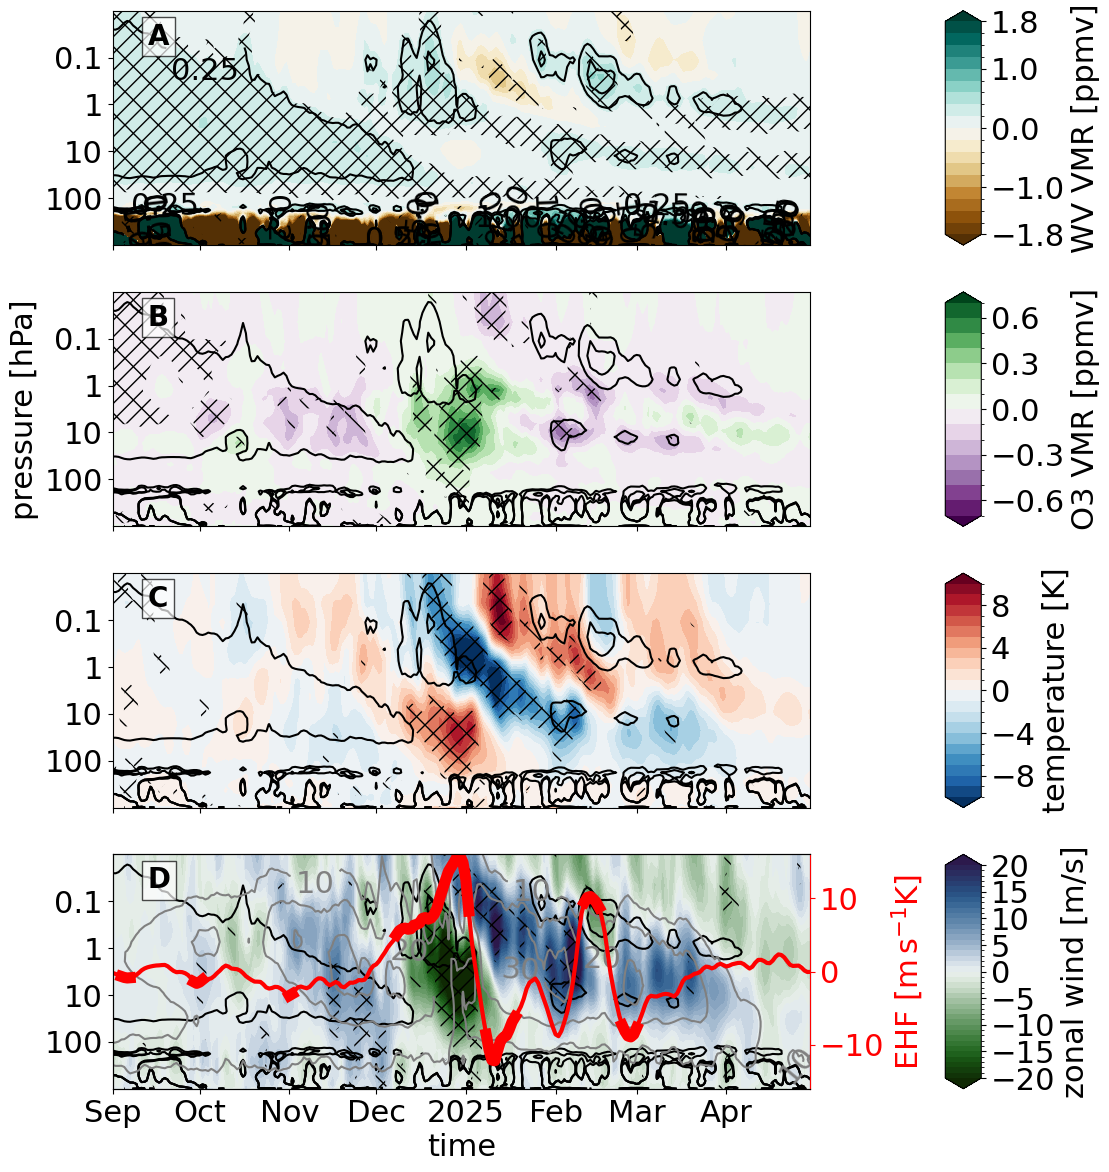

In [29]:
n_rows = 4
t_cmax = 10
t_cmax_step = 1

time_sel_dict = dict(plev = slice(0.1,200)) # time = slice("2023-09", "2024-04"),

f, axes = plt.subplots(n_rows, 1, figsize=(9, 14), sharex=True)
p_ls = []
ax = axes[0]
p = (diff_sel_pcap).plot.contourf(
    x = 'time', yincrease = False, 
    robust=False, cmap="BrBG", 
    extend = 'both',     
    levels = np.arange(-1.8,2,0.2), ax = ax,
    add_colorbar = False,
)
p_ls.append(p)
CS = (diff_sel_pcap).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.25,0.5,1], colors = ['k'],
)
ax.clabel(CS)

kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    ax=ax,
    # linewidths=np.linspace(1, 4, 4),
)

diff_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)
kwargs['levels'] = [0,0.1]
kwargs['hatches'] = ["\\",  None]
diff_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)


# ozone
ax = axes[1]
p = (diff_o3.squeeze()).plot.contourf(
    x = 'time', yincrease = False, 
    robust=True, levels = np.arange(-0.7,0.8,0.1),
    cmap = 'PRGn',
    ax = ax, extend='both',
    add_colorbar = False,
)
p_ls.append(p)

kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    ax=ax,
    # linewidths=np.linspace(1, 4, 4),
)

(diff_o3_pv.squeeze()).plot.contourf(x="time", **kwargs)
kwargs['levels'] = [0,0.1]
kwargs['hatches'] = ["\\",  None]
diff_o3_pv.squeeze().plot.contourf(x="time", **kwargs)

CS = (diff_sel_pcap).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.25,0.5,1], colors = ['k'],
)
#ax.clabel(CS)

# temperature
ax = axes[2]
p = (diff_t_sel_pcap).plot.contourf(
    x = 'time', yincrease = False, 
    robust=True, levels = np.arange(-t_cmax,t_cmax+t_cmax_step,t_cmax_step),##np.arange(-18,20,2),
    ax = ax, extend='both', cmap = 'RdBu_r',
    add_colorbar = False,
)
p_ls.append(p)

CS = (diff_sel_pcap).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.25,0.5,1], colors = ['k'],
)

kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    ax=ax,
    # linewidths=np.linspace(1, 4, 4),
)

diff_t_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)
kwargs['levels'] = [0,0.1]
kwargs['hatches'] = ["\\",  None]
diff_t_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)



# zonal wind
ax = axes[-1]
cm = Colormap('cork_r')  #'crameri:vik')
cmap = cm.to_matplotlib()

p2 = diff_u_sel_pcap.plot.contourf(
    x = 'time', yincrease = False, 
    robust=True, levels = np.arange(-20,21,1),
    ax = ax, extend='both',
    cmap = cmap,
    add_colorbar = False,
)
p_ls.append(p2)

CS = (diff_sel_pcap).plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [0.25,0.5,1], colors = ['k'],
)
#ax.clabel(CS)

CS = arr1_u.mean('ens').plot.contour(
    x = 'time', ax = ax, yincrease = False, 
    levels = [10,20,30], colors = ['gray'],
)
ax.clabel(CS)

kwargs = dict(
    yincrease= False,
    # colors=("k"),
    add_colorbar=False,
    levels=[0, 0.05],
    colors="none",
    hatches=[
        "//",
        None,
    ],
    ax=ax,
    # linewidths=np.linspace(1, 4, 4),
)
diff_u_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)
kwargs['levels'] = [0,0.1]
kwargs['hatches'] = ["\\",  None]
diff_u_sel_pcap_pv.squeeze().plot.contourf(x="time", **kwargs)
ax.set_title('')

for i,ax in enumerate(axes):
    ax.set_yscale('log')
    ax.set_yticks([100,10,1,0.1])
    fmt = mpl.ticker.FormatStrFormatter("%g")
    ax.yaxis.set_major_formatter(fmt)
    
    label = ascii_uppercase[i]
    ax.text(
            0.05,
            0.95,
            label,
            transform=ax.transAxes,
            fontsize=20,
            fontweight="bold",
            va="top",
            bbox={"alpha": 0.7, "facecolor": "white"},
        )
    if i != 1:
        ax.set_ylabel('')
    if i != n_rows-1:
        ax.set_xlabel('')

ax2 = ax.twinx()
temp = ds_diff_2425.sel(plev = 100, method='nearest')#.sel(time = time_slice)
temp['ehf'].plot(ax = ax2, color = 'red', lw = 3)
temp['ehf'].where(temp['pv'] < 0.1).plot(ax = ax2, color = 'red', lw = 8)

ax2.set_ylim(-16,16)
ax2.set_title('')
kwargs = dict(color = 'r')
ax2.set_ylabel(r'EHF [$\mathrm{m\,s^{-1} K}$]',  **kwargs)
ax2.spines['right'].set_color('red')
#ax2.yaxis.label.set_color('red')
ax2.tick_params(axis='y', colors='red')

cx_shift= 0.15
label_ls = ['WV VMR [ppmv]','O3 VMR [ppmv]','temperature [K]']
ticks_ls = [[-1.8,-1,0,1,1.8],[-0.9,-0.6,-0.3,0,0.3,0.6,0.9],[-16,-12,-8,-4,0,4,8,12,16],[-2,-1,0,1,2]]
for i, label, p, ticks in zip(range(3),label_ls,p_ls, ticks_ls):
    posn = axes[i].get_position()
    cax = f.add_axes([0.1,-0.1,0.5,0.1])
    
    cax.set_position([posn.x0+posn.width+cx_shift, posn.y0+0.0, 0.04, posn.height])
    f.colorbar(p, cax=cax, orientation='vertical', label=label, extend = 'both', spacing = 'proportional', ticks = ticks)

posn = axes[-1].get_position()
cax = f.add_axes([0.1,-0.1,0.5,0.1])
cx_shift= 0.15
cax.set_position([posn.x0+posn.width+cx_shift, posn.y0+0.0, 0.04, posn.height])
f.colorbar(p2, cax=cax, orientation='vertical', label='zonal wind [m/s]', extend = 'both', spacing = 'proportional', ticks = [-20,-15,-10,-5,0,5,10,15,20])


outfile = f"TE+U+WV+O3_time-evolution_2024-2025.pdf"
print(outfile)
plt.savefig(outfile, bbox_inches="tight")

In [30]:
from run_webdav_boku import run_client

client = run_client()
client.exists(f"HT_analysis/figs/strengthening/{outfile}")


True

In [31]:
#client.ls("Photos", detail=False)
client.upload_file(outfile, f"HT_analysis/figs/strengthening/{outfile}", overwrite=True)